In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
load_dotenv()

llm = ChatOpenAI(model = 'gpt-5-nano')

In [4]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [6]:
def genereate_joke(state:JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [7]:
def generate_explanation(state:JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'

    response = llm.invoke(prompt).content
    return {'explanation': response}

In [8]:
graph = StateGraph(JokeState)

graph.add_node('genereate_joke', genereate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'genereate_joke')
graph.add_edge('genereate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer = checkpointer)

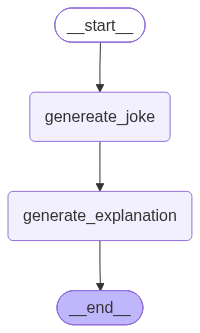

In [9]:
workflow

In [10]:
config1 = {"configurable": {"thread_id": "1"}}
chat = workflow.invoke({'topic': 'pizza'},config=config1)

In [11]:
print(f'chat: {chat["topic"]} \n\n Joke: {chat["joke"]} \n\n Explanation: {chat["explanation"]}')

chat: pizza 

 Joke: Here's a quick pizza joke:

Why did the pizza apply for a job? It needed the dough. 

 Explanation: This joke hinges on a pun and light misdirection.

- Setup: “Why did the pizza apply for a job?” makes you picture a pizza acting like a person, which is silly.
- Punchline: “It needed the dough.” Here, “dough” is used in two senses at once:
  - Pizza dough (the actual ingredient used to make pizza).
  - Dough as slang for money (the pay you’d get from a job).
- The humor comes from the double meaning (a pun): the pizza wants a job to earn money, but the word “dough” is also literally what pizza is made from.

If you want more variations, you could say:
- “Why did the bread apply for a job? It needed some dough.”
- “Why did the bakery hire the dough? It kneaded the business.” (pun on “knead”/“need”)


In [12]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Here's a quick pizza joke:\n\nWhy did the pizza apply for a job? It needed the dough.", 'explanation': 'This joke hinges on a pun and light misdirection.\n\n- Setup: “Why did the pizza apply for a job?” makes you picture a pizza acting like a person, which is silly.\n- Punchline: “It needed the dough.” Here, “dough” is used in two senses at once:\n  - Pizza dough (the actual ingredient used to make pizza).\n  - Dough as slang for money (the pay you’d get from a job).\n- The humor comes from the double meaning (a pun): the pizza wants a job to earn money, but the word “dough” is also literally what pizza is made from.\n\nIf you want more variations, you could say:\n- “Why did the bread apply for a job? It needed some dough.”\n- “Why did the bakery hire the dough? It kneaded the business.” (pun on “knead”/“need”)'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18b536-0350-645d-8002-0aff5aeb6

# **Time Travel**

In [13]:
workflow.get_state({"configurable": {"thread_id":"1", "checkpoint_id": "1f18b536-0350-645d-8002-0aff5aeb632b"}})

StateSnapshot(values={'topic': 'pizza', 'joke': "Here's a quick pizza joke:\n\nWhy did the pizza apply for a job? It needed the dough.", 'explanation': 'This joke hinges on a pun and light misdirection.\n\n- Setup: “Why did the pizza apply for a job?” makes you picture a pizza acting like a person, which is silly.\n- Punchline: “It needed the dough.” Here, “dough” is used in two senses at once:\n  - Pizza dough (the actual ingredient used to make pizza).\n  - Dough as slang for money (the pay you’d get from a job).\n- The humor comes from the double meaning (a pun): the pizza wants a job to earn money, but the word “dough” is also literally what pizza is made from.\n\nIf you want more variations, you could say:\n- “Why did the bread apply for a job? It needed some dough.”\n- “Why did the bakery hire the dough? It kneaded the business.” (pun on “knead”/“need”)'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f18b536-0350-645d-8002-0aff5aeb632b'}}, metadata={'sou

In [14]:
workflow.invoke(None, {"configurable": {"thread_id":"1", "checkpoint_id": "1f18b536-0350-645d-8002-0aff5aeb632b"}})

{'topic': 'pizza',
 'joke': "Here's a quick pizza joke:\n\nWhy did the pizza apply for a job? It needed the dough.",
 'explanation': 'This joke hinges on a pun and light misdirection.\n\n- Setup: “Why did the pizza apply for a job?” makes you picture a pizza acting like a person, which is silly.\n- Punchline: “It needed the dough.” Here, “dough” is used in two senses at once:\n  - Pizza dough (the actual ingredient used to make pizza).\n  - Dough as slang for money (the pay you’d get from a job).\n- The humor comes from the double meaning (a pun): the pizza wants a job to earn money, but the word “dough” is also literally what pizza is made from.\n\nIf you want more variations, you could say:\n- “Why did the bread apply for a job? It needed some dough.”\n- “Why did the bakery hire the dough? It kneaded the business.” (pun on “knead”/“need”)'}

# **Update State**

In [16]:
workflow.update_state({"configurable": {"thread_id":"1", "checkpoint_id": "1f18b536-0350-645d-8002-0aff5aeb632b", "checkpoint_ns":""}}, {'topic': 'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18b546-0580-674a-8003-8e0326e04adf'}}

In [19]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': "Here's a quick pizza joke:\n\nWhy did the pizza apply for a job? It needed the dough.", 'explanation': 'This joke hinges on a pun and light misdirection.\n\n- Setup: “Why did the pizza apply for a job?” makes you picture a pizza acting like a person, which is silly.\n- Punchline: “It needed the dough.” Here, “dough” is used in two senses at once:\n  - Pizza dough (the actual ingredient used to make pizza).\n  - Dough as slang for money (the pay you’d get from a job).\n- The humor comes from the double meaning (a pun): the pizza wants a job to earn money, but the word “dough” is also literally what pizza is made from.\n\nIf you want more variations, you could say:\n- “Why did the bread apply for a job? It needed some dough.”\n- “Why did the bakery hire the dough? It kneaded the business.” (pun on “knead”/“need”)'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18b546-0580-674a-8003-8e0326e0

In [18]:
workflow.invoke(None, {"configurable": {"thread_id":"1", "checkpoint_id": "1f18b546-0580-674a-8003-8e0326e04adf"}})

{'topic': 'samosa',
 'joke': "Here's a quick pizza joke:\n\nWhy did the pizza apply for a job? It needed the dough.",
 'explanation': 'This joke hinges on a pun and light misdirection.\n\n- Setup: “Why did the pizza apply for a job?” makes you picture a pizza acting like a person, which is silly.\n- Punchline: “It needed the dough.” Here, “dough” is used in two senses at once:\n  - Pizza dough (the actual ingredient used to make pizza).\n  - Dough as slang for money (the pay you’d get from a job).\n- The humor comes from the double meaning (a pun): the pizza wants a job to earn money, but the word “dough” is also literally what pizza is made from.\n\nIf you want more variations, you could say:\n- “Why did the bread apply for a job? It needed some dough.”\n- “Why did the bakery hire the dough? It kneaded the business.” (pun on “knead”/“need”)'}